# Cybersecurity Benchmark

This notebook imports saved cybersecurity runs from `results/cybersecurity`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    discrete_transport_tv_bound_table,
    load_runs,
    objective_table,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
)

ENV = 'cybersecurity'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 25 saved runs from /home/adonis/Internship/mfc/results/cybersecurity


## Validation Reward

Mean validation reward over training, with one standard deviation across the five seeds. This compares REINFORCE, MF-REINFORCE, and transport for each perturbation level.

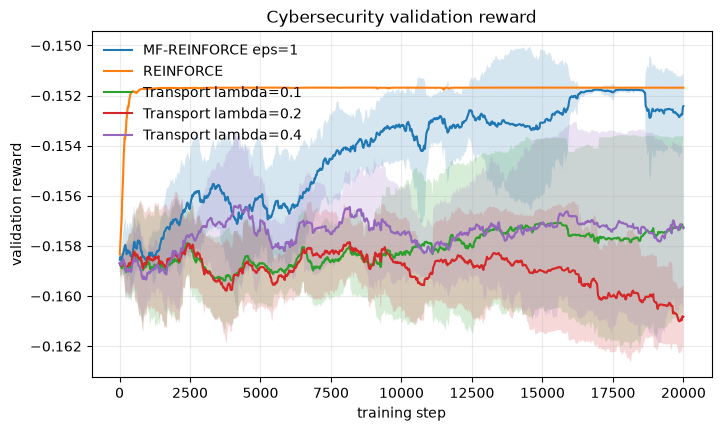

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=3, flow='exact', ax=ax)
    ax.set_title('Cybersecurity validation reward')
    plt.show()

## Learned State Distribution Flow

State-probability trajectories under the best saved policy for each algorithm and perturbation. The four curves correspond to DI, DS, UI, and US.

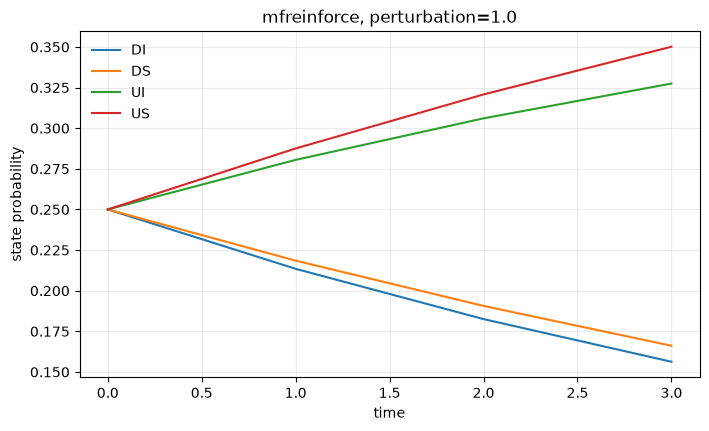

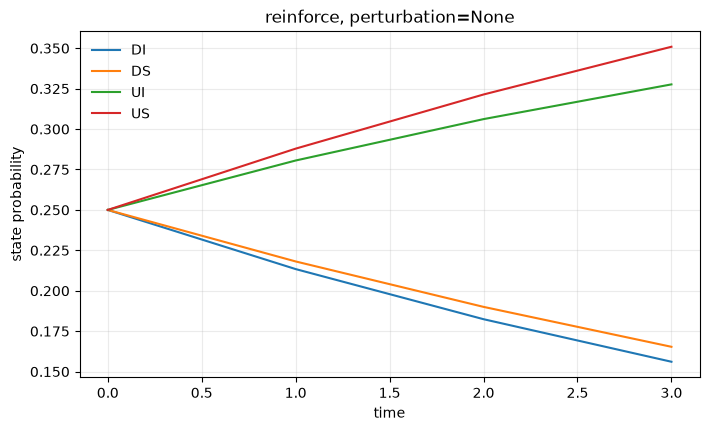

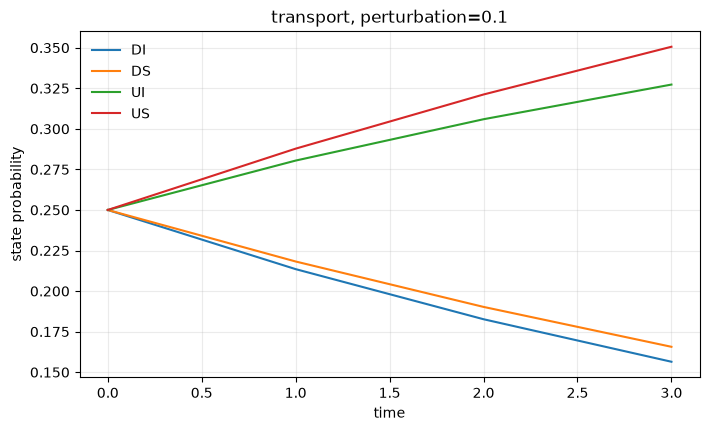

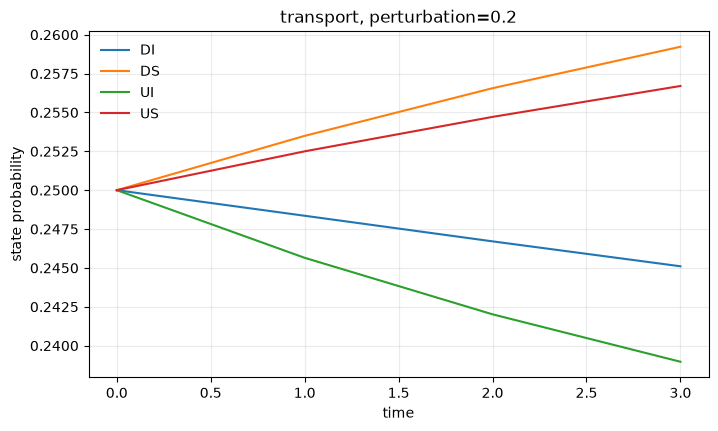

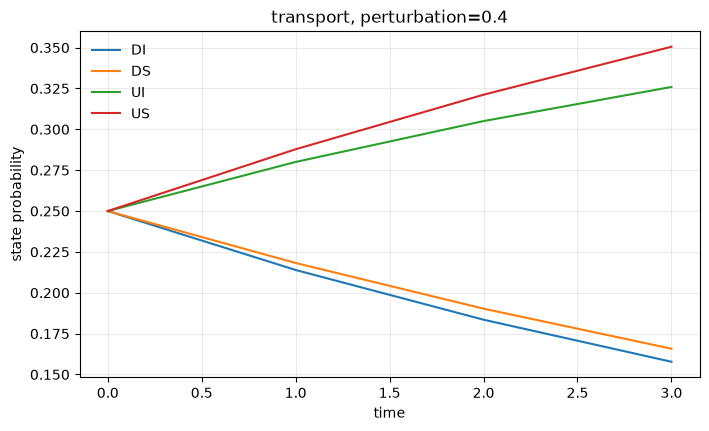

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, perturbation={meta['perturbation']}")
    plt.show()

## Transport Perturbation Bound

For simplex transport, the total-variation distance between the perturbed population law and the unperturbed law is bounded by the selected perturbation level.

In [4]:
tv_bounds = discrete_transport_tv_bound_table(runs)
display(tv_bounds if not tv_bounds.empty else pd.DataFrame({'message': ['No transport runs found yet.']}))

,env,label,flow,horizon,seed,lambda,max_tv_upper_bound,satisfies_lambda_bound
0,cybersecurity,Transport lambda=0.1,exact,3,0,0.1,0.078550,True
1,cybersecurity,Transport lambda=0.1,exact,3,1,0.1,0.084356,True
2,cybersecurity,Transport lambda=0.1,exact,3,2,0.1,0.078831,True
3,cybersecurity,Transport lambda=0.1,exact,3,3,0.1,0.081331,True
4,cybersecurity,Transport lambda=0.1,exact,3,4,0.1,0.076006,True
5,cybersecurity,Transport lambda=0.2,exact,3,0,0.2,0.164420,True
6,cybersecurity,Transport lambda=0.2,exact,3,1,0.2,0.158696,True
7,cybersecurity,Transport lambda=0.2,exact,3,2,0.2,0.158786,True
8,cybersecurity,Transport lambda=0.2,exact,3,3,0.2,0.164937,True
9,cybersecurity,Transport lambda=0.2,exact,3,4,0.2,0.152207,True


## Objective and Runtime Tables

Final validation rewards, estimated simulator budgets, and average runtime per algorithm configuration.

In [5]:
display(objective_table(runs))
display(runtime_table(runs))

,env,label,flow,horizon,seed,validation_reward
0,cybersecurity,MF-REINFORCE eps=1,exact,3,0,-0.151723
1,cybersecurity,MF-REINFORCE eps=1,exact,3,1,-0.154711
2,cybersecurity,MF-REINFORCE eps=1,exact,3,2,-0.151721
3,cybersecurity,MF-REINFORCE eps=1,exact,3,3,-0.152204
4,cybersecurity,MF-REINFORCE eps=1,exact,3,4,-0.151748
5,cybersecurity,REINFORCE,exact,3,0,-0.151698
6,cybersecurity,REINFORCE,exact,3,1,-0.151681
7,cybersecurity,REINFORCE,exact,3,2,-0.151684
8,cybersecurity,REINFORCE,exact,3,3,-0.151681
9,cybersecurity,REINFORCE,exact,3,4,-0.151681


,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,cybersecurity,mfreinforce,1.0,3,exact,9.085277,0.971722,666.412402,5.845455,370.195447,4.275030,1045.754884,10.486754,0.033321,0.052288,0.185098,612.0,5
1,cybersecurity,reinforce,NaN,3,exact,7.281965,0.149351,89.247779,0.397707,368.883976,1.809814,465.473321,1.954777,0.004462,0.023274,0.184442,612.0,5
2,cybersecurity,transport,0.1,3,exact,8.479657,0.333342,564.381344,1.343998,369.960515,0.984746,942.880741,2.319192,0.028219,0.047144,0.184980,612.0,5
3,cybersecurity,transport,0.2,3,exact,7.982142,1.189670,567.540367,2.732425,373.054598,1.963744,948.637240,4.578519,0.028377,0.047432,0.186527,612.0,5
4,cybersecurity,transport,0.4,3,exact,8.422073,2.371662,570.188931,3.433175,373.284476,2.054662,951.960437,6.559872,0.028509,0.047598,0.186642,612.0,5
